In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import xgboost as xgb
import joblib
import os
import warnings
from sklearn.metrics import mean_absolute_error, mean_squared_error

# Configuración visual y advertencias
warnings.filterwarnings('ignore')
sns.set_palette(["#34495e", "#e74c3c", "#2ecc71", "#3498db"])
plt.style.use('ggplot')

print("Librerías importadas correctamente. Listos para iniciar.")

Librerías importadas correctamente. Listos para iniciar.


In [2]:
print("Cargando datos...")
train = pd.read_parquet('m5_train.parquet')
val   = pd.read_parquet('m5_val.parquet')

print(f"Train original: {train.shape}")
print(f"Val original:   {val.shape}")

# 1. Definir características Ahora incluimos el contexto categórico
CAT_FEATURES = ['item_id', 'dept_id', 'cat_id', 'store_id', 'state_id']
NUM_FEATURES = ['lag_7', 'lag_21', 'lag_28', 'lag_60',
                'ma_7',  'ma_21',  'ma_28',  'ma_60',
                'std_7', 'std_28',
                'wday', 'month', 'snap', 'sell_price']

FEATURES = CAT_FEATURES + NUM_FEATURES

# 2. Limpiar nulos generados por los rezagos (lags)
train_clean = train.dropna(subset=NUM_FEATURES).copy()
val_clean   = val.dropna(subset=NUM_FEATURES).copy()

# 3. Convertir explícitamente a tipo 'category' 
for col in CAT_FEATURES:
    # Verificamos que existan en el dataset antes de castear
    if col in train_clean.columns:
        train_clean[col] = train_clean[col].astype('category')
        val_clean[col]   = val_clean[col].astype('category')

# 4. Separar X e y
X_train = train_clean[FEATURES]
y_train = train_clean['ventas']

X_val = val_clean[FEATURES]
y_val = val_clean['ventas']

print(f"\nTrain limpio: {train_clean.shape}")
print(f"Val limpio:   {val_clean.shape}")
print(f"% ceros en train: {(y_train == 0).mean()*100:.1f}%")

Cargando datos...
Train original: (58327370, 27)
Val original:   (853720, 27)

Train limpio: (45258166, 27)
Val limpio:   (853720, 27)
% ceros en train: 59.9%


In [3]:
# Configuración del modelo XGBoost Regressor
reg = xgb.XGBRegressor(
    objective='reg:tweedie',      # Objetivo ideal para muchos ceros y asimetría
    tweedie_variance_power=1.1,   # Distribución Poisson-Gamma
    n_estimators=800,             # Aumentamos ligeramente los árboles al tener más features
    learning_rate=0.05,
    max_depth=8,
    subsample=0.8,
    colsample_bytree=0.8,
    tree_method='hist',           # Vital para velocidad y manejo de categóricas
    enable_categorical=True,      # Activa el soporte nativo para variables de texto/categorías
    eval_metric=['rmse', 'mae'],  # Evaluamos con las métricas que nos importan
    random_state=42,
    n_jobs=-1
)

print("\nIniciando entrenamiento del XGBoost Mejorado...")
reg.fit(
    X_train, y_train,
    eval_set=[(X_train, y_train), (X_val, y_val)],
    verbose=50
)
print("Entrenamiento completado.")


Iniciando entrenamiento del XGBoost Mejorado...
[0]	validation_0-rmse:4.22583	validation_0-mae:1.78749	validation_1-rmse:3.57845	validation_1-mae:1.68957
[50]	validation_0-rmse:2.38142	validation_0-mae:1.00824	validation_1-rmse:1.98115	validation_1-mae:1.01366
[100]	validation_0-rmse:2.33069	validation_0-mae:0.97781	validation_1-rmse:1.95305	validation_1-mae:0.99139
[150]	validation_0-rmse:2.32088	validation_0-mae:0.97362	validation_1-rmse:1.95032	validation_1-mae:0.98836
[200]	validation_0-rmse:2.31515	validation_0-mae:0.97175	validation_1-rmse:1.94896	validation_1-mae:0.98716
[250]	validation_0-rmse:2.31106	validation_0-mae:0.97060	validation_1-rmse:1.94831	validation_1-mae:0.98654
[300]	validation_0-rmse:2.30653	validation_0-mae:0.96953	validation_1-rmse:1.94739	validation_1-mae:0.98590
[350]	validation_0-rmse:2.30125	validation_0-mae:0.96846	validation_1-rmse:1.94679	validation_1-mae:0.98532
[400]	validation_0-rmse:2.29550	validation_0-mae:0.96761	validation_1-rmse:1.94663	validat

In [4]:
# Generar predicciones 
y_pred_final = np.clip(reg.predict(X_val), 0, None)

# Métricas estándar
mae  = mean_absolute_error(y_val, y_pred_final)
rmse = np.sqrt(mean_squared_error(y_val, y_pred_final))

# Función rápida para aproximar WRMSSE a nivel de item 
def calcular_wrmsse_rapido(y_pred, df_val_clean, df_train_clean):
    df_val = df_val_clean[['id', 'ventas']].copy()
    df_val['pred'] = y_pred

    err = df_val.groupby('id').apply(
        lambda x: np.mean((x['ventas'].values - x['pred'].values) ** 2)
    ).reset_index(name='mse')

    escala = df_train_clean.groupby('id')['ventas'].apply(
        lambda x: np.mean(np.diff(x.values) ** 2)
    ).reset_index(name='escala')

    peso = df_train_clean.groupby('id')['ventas'].sum().reset_index(name='peso')

    df_m = err.merge(escala, on='id').merge(peso, on='id')
    df_m = df_m[df_m['escala'] > 0]

    return np.sqrt(np.average(df_m['mse'] / df_m['escala'], weights=df_m['peso']))

print("\nCalculando WRMSSE...")
wrmsse_score = calcular_wrmsse_rapido(y_pred_final, val_clean, train_clean)

print("=" * 45)
print("   RESULTADOS DEL MODELO XGBOOST TWEEDIE")
print("=" * 45)
print(f"  MAE                   : {mae:.4f}")
print(f"  RMSE                  : {rmse:.4f}")
print(f"  WRMSSE                : {wrmsse_score:.4f}")
print("=" * 45)


Calculando WRMSSE...
   RESULTADOS DEL MODELO XGBOOST TWEEDIE
  MAE                   : 0.9833
  RMSE                  : 1.9455
  WRMSSE                : 0.7392


In [5]:
# Predecir en train para comparar
y_pred_train = np.clip(reg.predict(X_train), 0, None)

mae_train  = mean_absolute_error(y_train, y_pred_train)
rmse_train = np.sqrt(mean_squared_error(y_train, y_pred_train))

print("=" * 45)
print("   VERIFICACIÓN DE SOBREAJUSTE")
print("=" * 45)
print(f"{'Métrica':<10} {'Train':>10} {'Val':>10} {'Diferencia':>12}")
print("-" * 45)
print(f"{'MAE':<10} {mae_train:>10.4f} {mae:>10.4f} {abs(mae_train-mae):>12.4f}")
print(f"{'RMSE':<10} {rmse_train:>10.4f} {rmse:>10.4f} {abs(rmse_train-rmse):>12.4f}")
print("=" * 45)

   VERIFICACIÓN DE SOBREAJUSTE
Métrica         Train        Val   Diferencia
---------------------------------------------
MAE            0.9632     0.9833       0.0201
RMSE           2.2622     1.9455       0.3167


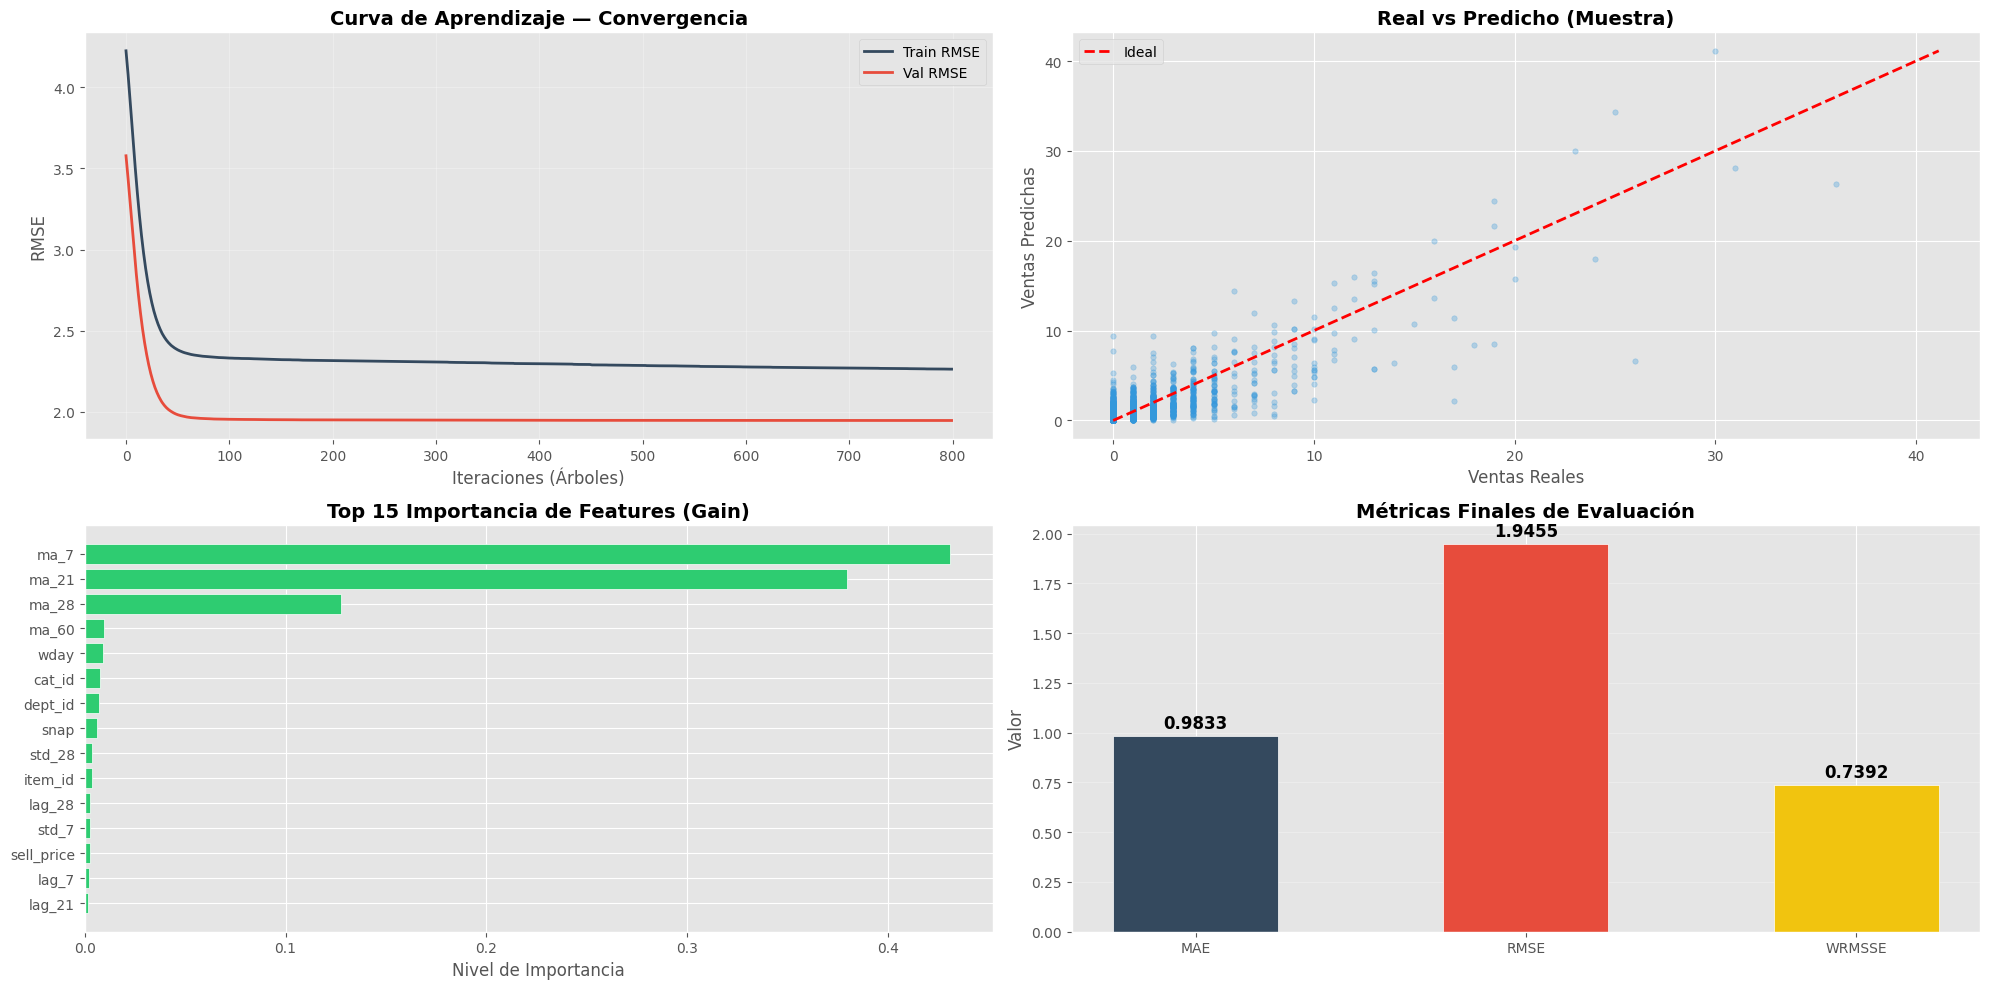

In [6]:
# Extraer resultados de evaluación
resultados = reg.evals_result()

fig = plt.figure(figsize=(20, 10))
gs = fig.add_gridspec(2, 2)

# --- 1. Curva de Aprendizaje (RMSE) ---
ax1 = fig.add_subplot(gs[0, 0])
ax1.plot(resultados['validation_0']['rmse'], label='Train RMSE', color='#34495e', linewidth=2)
ax1.plot(resultados['validation_1']['rmse'], label='Val RMSE', color='#e74c3c', linewidth=2)
ax1.set_title('Curva de Aprendizaje — Convergencia', fontsize=14, fontweight='bold')
ax1.set_xlabel('Iteraciones (Árboles)')
ax1.set_ylabel('RMSE')
ax1.legend()
ax1.grid(alpha=0.3)

# --- 2. Real vs Predicho ---
ax2 = fig.add_subplot(gs[0, 1])
sample = np.random.choice(len(y_val), size=2500, replace=False)
ax2.scatter(y_val.values[sample], y_pred_final[sample], alpha=0.3, s=15, color='#3498db')
max_val = max(y_val.values[sample].max(), y_pred_final[sample].max())
ax2.plot([0, max_val], [0, max_val], 'r--', linewidth=2, label='Ideal')
ax2.set_title('Real vs Predicho (Muestra)', fontsize=14, fontweight='bold')
ax2.set_xlabel('Ventas Reales')
ax2.set_ylabel('Ventas Predichas')
ax2.legend()

# --- 3. Importancia de Features ---
ax3 = fig.add_subplot(gs[1, 0])
importancia = pd.DataFrame({
    'feature': FEATURES,
    'importance': reg.feature_importances_
}).sort_values('importance', ascending=True)

# Tomamos las top 15 
top_importancia = importancia.tail(15)
ax3.barh(top_importancia['feature'], top_importancia['importance'], color='#2ecc71', edgecolor='white')
ax3.set_title('Top 15 Importancia de Features (Gain)', fontsize=14, fontweight='bold')
ax3.set_xlabel('Nivel de Importancia')

# --- 4. Resumen de Métricas ---
ax4 = fig.add_subplot(gs[1, 1])
metricas = ['MAE', 'RMSE', 'WRMSSE']
valores  = [mae, rmse, wrmsse_score]
colores  = ['#34495e', '#e74c3c', '#f1c40f']

bars = ax4.bar(metricas, valores, color=colores, edgecolor='white', width=0.5)
for bar, val in zip(bars, valores):
    ax4.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 0.02,
             f'{val:.4f}', ha='center', va='bottom', fontsize=12, fontweight='bold')
ax4.set_title('Métricas Finales de Evaluación', fontsize=14, fontweight='bold')
ax4.set_ylabel('Valor')
ax4.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

In [7]:
os.makedirs('modelos', exist_ok=True)
ruta_modelo = 'modelos/regresor_xgboost_tweedie.pkl'

# Guardado con joblib respetando tu formato anterior
joblib.dump(reg, ruta_modelo)

print(f"¡Modelo 'Mejorado' guardado en: {ruta_modelo}!")
print("Para cargarlo después utiliza:")
print("reg = joblib.load('modelos/regresor_xgboost_tweedie.pkl')")

¡Modelo 'Mejorado' guardado en: modelos/regresor_xgboost_tweedie.pkl!
Para cargarlo después utiliza:
reg = joblib.load('modelos/regresor_xgboost_tweedie.pkl')
